# Marketing Spend Optimization Engine

## Overview
This project builds a decision analytics engine to optimize multi-channel marketing budget allocation under a fixed total spend constraint.

**Business Problem:**
A marketing team has a fixed budget to allocate across 4 channels — TV, Digital, Influencer, and Search. The goal is to determine the allocation that maximizes predicted revenue.

**Key Questions Answered:**
- How does each channel contribute to revenue?
- What is the optimal budget allocation under a fixed spend constraint?
- How does the optimal allocation shift as total budget changes?
- What happens to revenue under different spend scenarios?

**Methodology:**
1. Simulated 120 weeks of realistic marketing spend data
2. Modeled revenue using Multiple Linear Regression with log-transformed features to capture diminishing returns
3. Validated model assumptions using R², VIF, and residual diagnostics
4. Solved a constrained optimization problem using SciPy to find optimal allocation
5. Ran scenario simulations to stress-test the model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load data
data = pd.read_csv("data/marketing_data.csv")
coeffs = pd.read_csv("data/model_coefficients.csv", index_col=0, header=None, skiprows=1)
coeffs.columns = ["value"]
coeffs = coeffs["value"]
optimization_results = pd.read_csv("data/optimization_results.csv")

print("Data loaded successfully")
print(f"Dataset shape: {data.shape}")
data.head()

Data loaded successfully
Dataset shape: (120, 6)


,week,tv_spend,digital_spend,influencer_spend,search_spend,revenue
0,1,219.868566,173.730958,64.149585,112.983663,7713.647665
1,2,194.469428,122.718376,77.705271,138.318473,7416.777116
2,3,225.907542,192.083829,90.099746,97.280996,7475.733625
3,4,260.921194,107.944468,97.315104,110.042793,7610.482297
4,5,190.633865,167.605713,55.994072,117.253600,7511.640326


## 1. Exploratory Data Analysis

Before building the model, let's understand the distribution of spend across channels and how they relate to revenue.

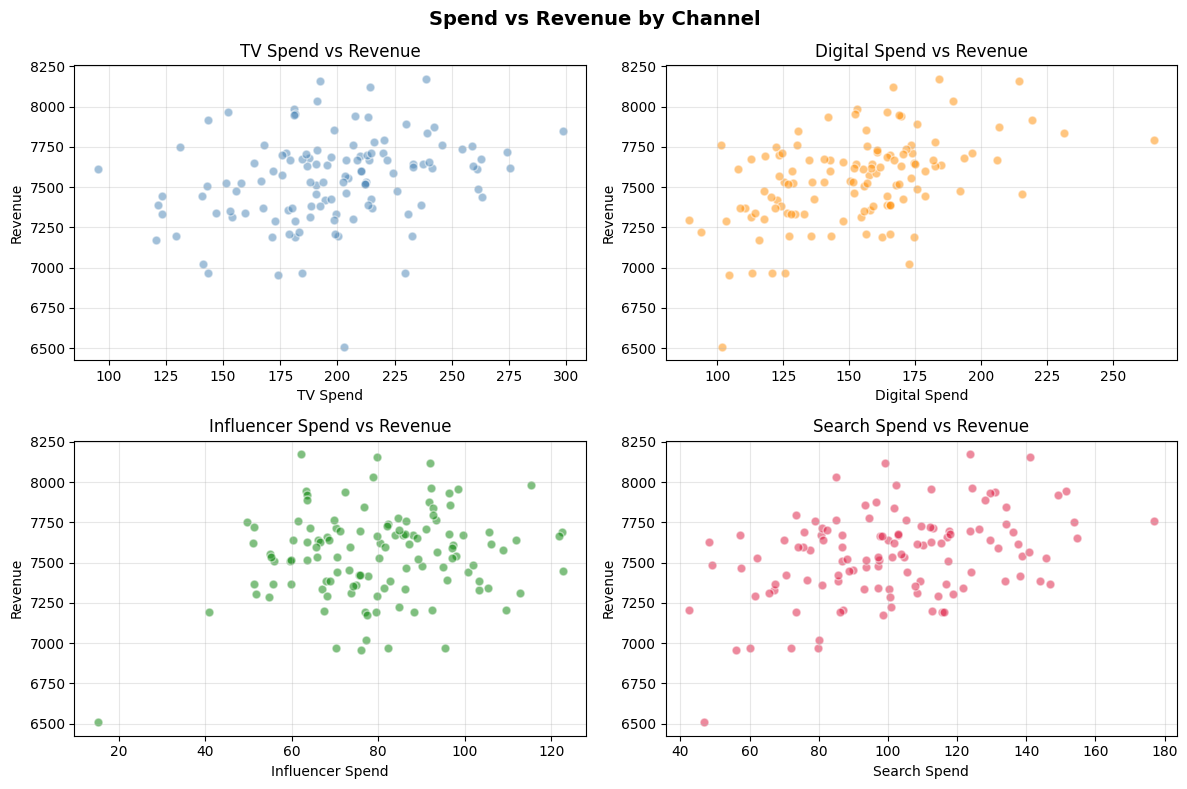

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

channels = ["tv_spend", "digital_spend", "influencer_spend", "search_spend"]
colors = ["steelblue", "darkorange", "green", "crimson"]
titles = ["TV Spend", "Digital Spend", "Influencer Spend", "Search Spend"]

for i, (channel, color, title) in enumerate(zip(channels, colors, titles)):
    axes[i].scatter(data[channel], data["revenue"], color=color, alpha=0.5, edgecolors="white", s=40)
    axes[i].set_xlabel(title)
    axes[i].set_ylabel("Revenue")
    axes[i].set_title(f"{title} vs Revenue")
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Spend vs Revenue by Channel", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Regression Model

We use Multiple Linear Regression with log-transformed spend features to capture diminishing returns — the idea that each additional dollar spent on a channel produces less incremental revenue than the previous dollar.

**Why log transformation?**
- Raw spend assumes linear returns (doubling spend = doubling revenue)
- Log-transformed spend captures the real-world reality that returns diminish as spend increases

In [3]:
# Log transform features
data["log_tv"] = np.log(data["tv_spend"] + 1)
data["log_digital"] = np.log(data["digital_spend"] + 1)
data["log_influencer"] = np.log(data["influencer_spend"] + 1)
data["log_search"] = np.log(data["search_spend"] + 1)

X = data[["log_tv", "log_digital", "log_influencer", "log_search"]]
y = data["revenue"]
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     30.90
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           1.83e-17
Time:                        15:04:51   Log-Likelihood:                -797.38
No. Observations:                 120   AIC:                             1605.
Df Residuals:                     115   BIC:                             1619.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           -331.4765    750.506     -0.

## 3. Model Validation

Before trusting the model's predictions, we validate two key assumptions:

**VIF (Variance Inflation Factor):**
- Checks for multicollinearity between features
- VIF < 5 means features are not highly correlated with each other
- High multicollinearity would make coefficient estimates unreliable

**Residual Plot:**
- Checks if errors are randomly distributed
- A good model should show no pattern in residuals

VIF Scores:
          feature          VIF
0           const  1871.626891
1          log_tv     1.029707
2     log_digital     1.047048
3  log_influencer     1.043177
4      log_search     1.009406


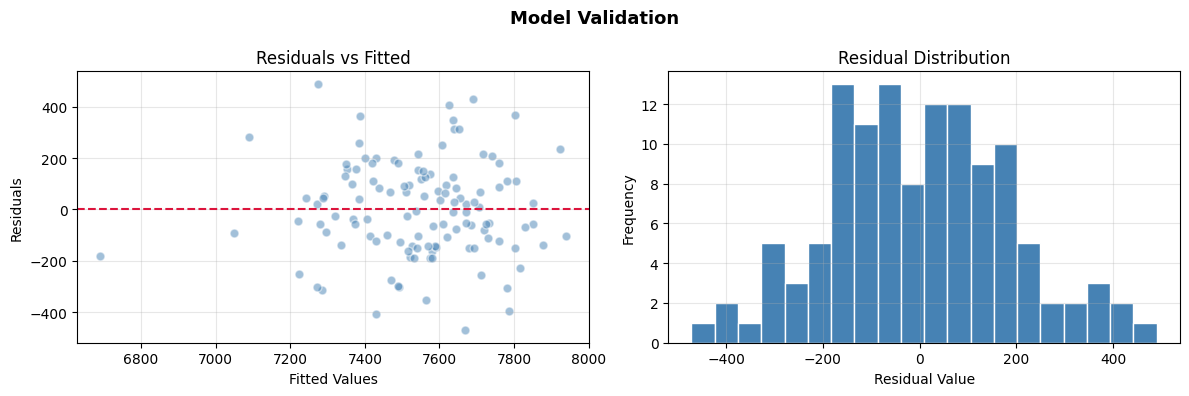

In [4]:
# VIF check
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("VIF Scores:")
print(vif_data)

# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs fitted
fitted = model.fittedvalues
residuals = model.resid

axes[0].scatter(fitted, residuals, alpha=0.5, color="steelblue", edgecolors="white", s=40)
axes[0].axhline(y=0, color="crimson", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")
axes[0].grid(True, alpha=0.3)

# Residual distribution
axes[1].hist(residuals, bins=20, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Residual Value")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Model Validation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Diminishing Returns Curves

The log transformation means each channel exhibits diminishing returns — spending more produces less incremental revenue per dollar. The curves below show this effect for each channel.

A steeper curve means higher ROI at low spend levels. A flatter curve means the channel saturates quickly.

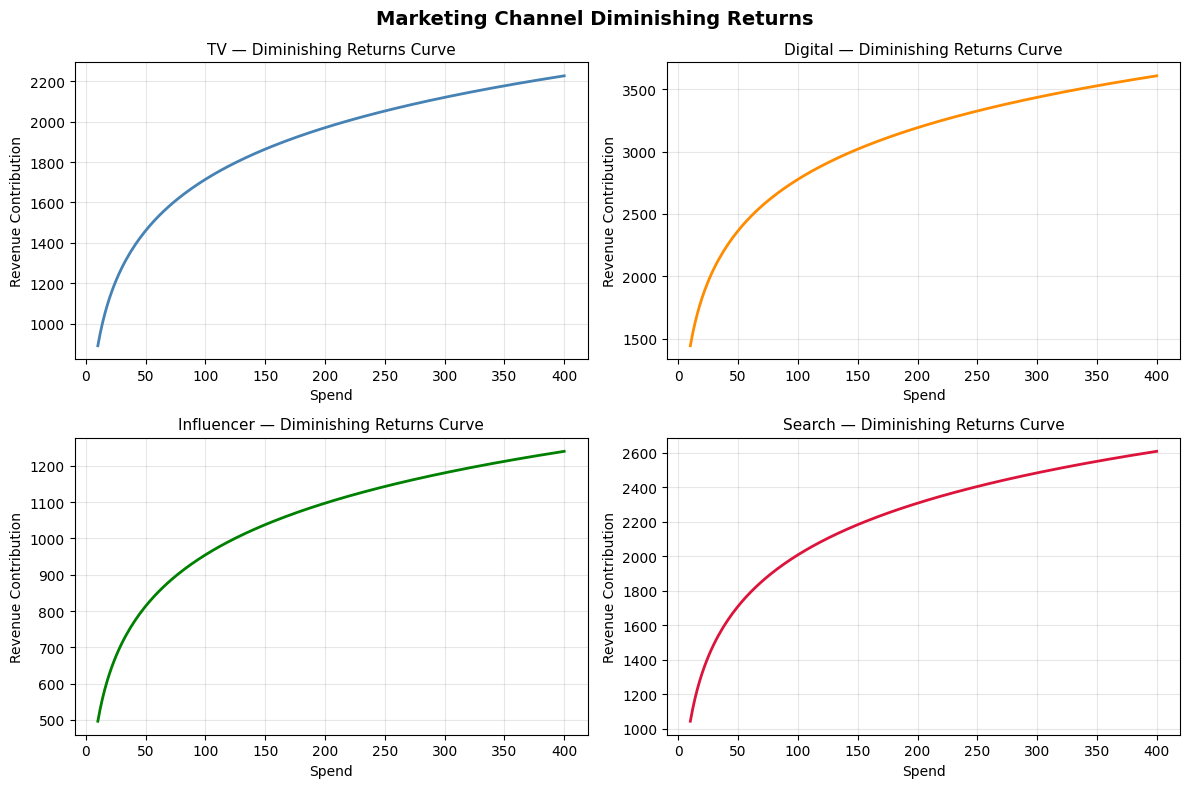

In [5]:
spend_range = np.linspace(10, 400, 200)

channels = {
    "TV":         ("log_tv",         "steelblue"),
    "Digital":    ("log_digital",    "darkorange"),
    "Influencer": ("log_influencer", "green"),
    "Search":     ("log_search",     "crimson"),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (channel, (coeff_key, color)) in enumerate(channels.items()):
    revenue = coeffs[coeff_key] * np.log(spend_range + 1)
    axes[i].plot(spend_range, revenue, color=color, linewidth=2)
    axes[i].set_title(f"{channel} — Diminishing Returns Curve", fontsize=11)
    axes[i].set_xlabel("Spend")
    axes[i].set_ylabel("Revenue Contribution")
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Marketing Channel Diminishing Returns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Constrained Budget Optimization

Using SciPy's minimize function, we solve for the optimal spend allocation across all 4 channels under a fixed total budget constraint.

**Optimization Setup:**
- Objective: Maximize predicted revenue
- Constraint: Total spend must equal the budget
- Bounds: Minimum spend of 10 per channel (zero spend is unrealistic)
- Method: SLSQP (Sequential Least Squares Programming)

Optimal Allocation by Budget Level:
-----------------------------------------------------------------
Budget           TV    Digital   Influencer     Search    Revenue
-----------------------------------------------------------------
400           91.91     149.53        50.75     107.81    7226.54
450          103.41     168.15        57.16     121.28    7415.02
500          114.91     186.79        63.56     134.74    7583.79
530          121.80     197.96        67.40     142.83    7677.18
600          137.90     224.04        76.37     161.69    7876.15
700          160.90     261.31        89.18     188.61    8123.63


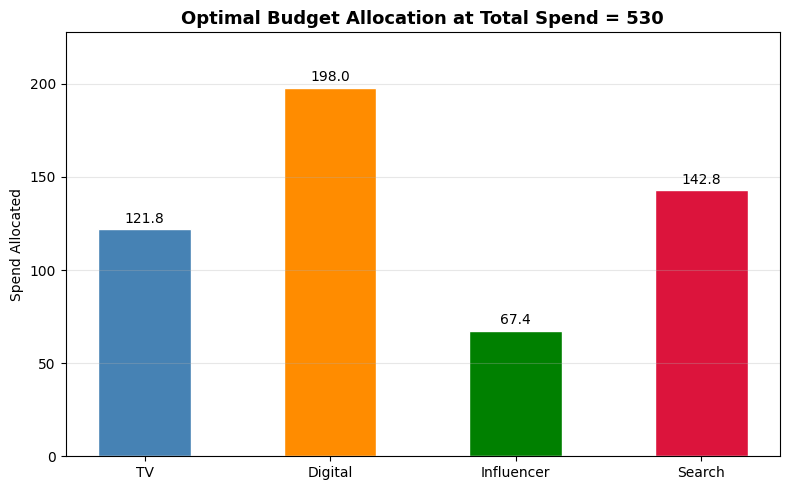

In [6]:
# Display optimization results across budgets
print("Optimal Allocation by Budget Level:")
print("-" * 65)
print(f"{'Budget':<10} {'TV':>8} {'Digital':>10} {'Influencer':>12} {'Search':>10} {'Revenue':>10}")
print("-" * 65)

for _, row in optimization_results.iterrows():
    print(f"{row['budget']:<10.0f} {row['tv']:>8.2f} {row['digital']:>10.2f} {row['influencer']:>12.2f} {row['search']:>10.2f} {row['revenue']:>10.2f}")

# Plot optimal allocation at budget 530
row_530 = optimization_results[optimization_results["budget"] == 530].iloc[0]
channels_list = ["TV", "Digital", "Influencer", "Search"]
allocations = [row_530["tv"], row_530["digital"], row_530["influencer"], row_530["search"]]
colors = ["steelblue", "darkorange", "green", "crimson"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(channels_list, allocations, color=colors, edgecolor="white", width=0.5)

for bar, val in zip(bars, allocations):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{val:.1f}", ha="center", va="bottom", fontsize=10)

ax.set_title("Optimal Budget Allocation at Total Spend = 530", fontsize=13, fontweight="bold")
ax.set_ylabel("Spend Allocated")
ax.set_ylim(0, max(allocations) * 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Revenue vs Budget Analysis

As total budget increases, predicted revenue grows but at a diminishing rate — consistent with the log transformation applied to each channel. This curve helps a marketing team justify budget increases to leadership by showing the expected revenue return.

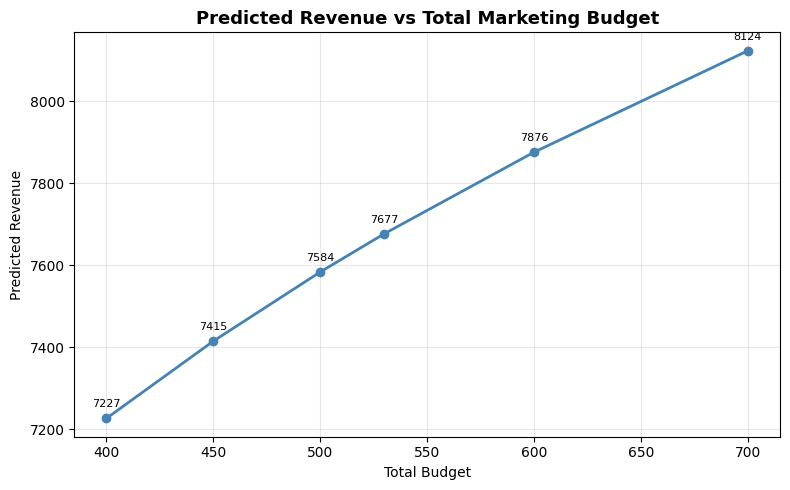

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(optimization_results["budget"], optimization_results["revenue"],
        marker="o", color="steelblue", linewidth=2, markersize=6)

for _, row in optimization_results.iterrows():
    ax.annotate(f"{row['revenue']:.0f}",
                (row["budget"], row["revenue"]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

ax.set_title("Predicted Revenue vs Total Marketing Budget", fontsize=13, fontweight="bold")
ax.set_xlabel("Total Budget")
ax.set_ylabel("Predicted Revenue")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Channel Allocation Shift by Budget

As total budget increases, the optimizer redistributes spend across channels. This chart shows how each channel's optimal allocation changes as more budget becomes available.

A channel that grows faster than others as budget increases is a high-ROI channel worth prioritizing when budget expands.

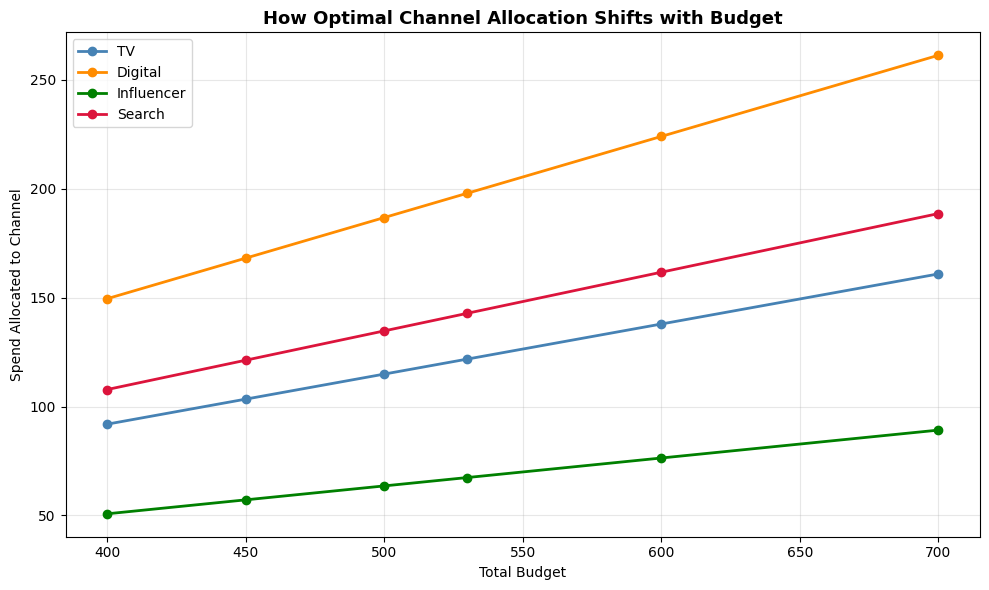

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(optimization_results["budget"], optimization_results["tv"],
        marker="o", label="TV", color="steelblue", linewidth=2)
ax.plot(optimization_results["budget"], optimization_results["digital"],
        marker="o", label="Digital", color="darkorange", linewidth=2)
ax.plot(optimization_results["budget"], optimization_results["influencer"],
        marker="o", label="Influencer", color="green", linewidth=2)
ax.plot(optimization_results["budget"], optimization_results["search"],
        marker="o", label="Search", color="crimson", linewidth=2)

ax.set_title("How Optimal Channel Allocation Shifts with Budget", fontsize=13, fontweight="bold")
ax.set_xlabel("Total Budget")
ax.set_ylabel("Spend Allocated to Channel")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Scenario Analysis

Instead of optimizing, we simulate specific business scenarios to understand the revenue impact of common marketing decisions — budget cuts, channel shifts, and overall spend changes.

This is useful for answering "what if" questions from leadership without running a full optimization.

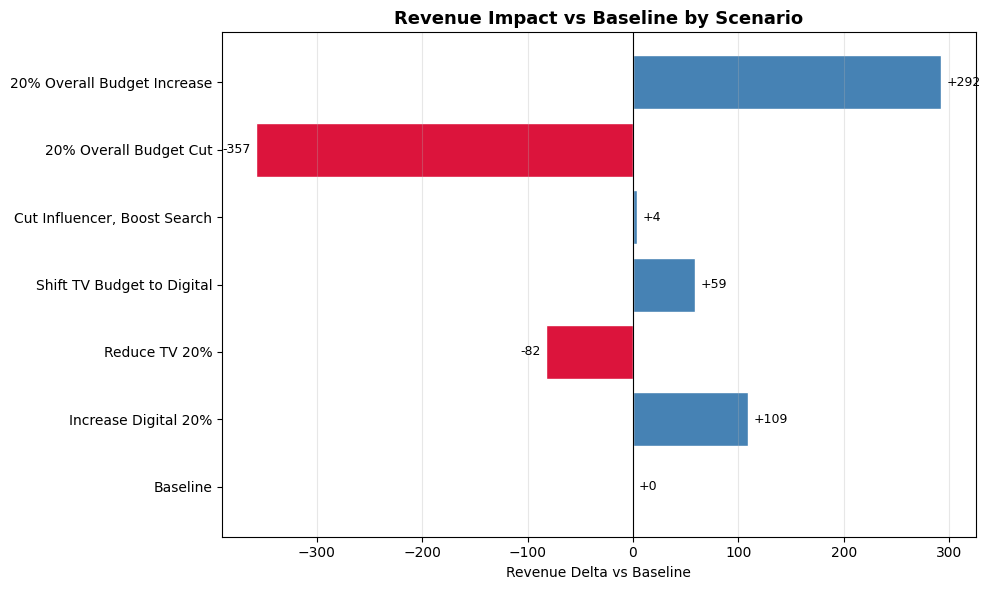

In [9]:
def predict_revenue(tv, digital, influencer, search):
    return (
        coeffs["log_tv"] * np.log(tv + 1) +
        coeffs["log_digital"] * np.log(digital + 1) +
        coeffs["log_influencer"] * np.log(influencer + 1) +
        coeffs["log_search"] * np.log(search + 1) +
        coeffs["const"]
    )

baseline = (200, 150, 80, 100)
baseline_revenue = predict_revenue(*baseline)

scenarios = {
    "Baseline":                    (200, 150, 80, 100),
    "Increase Digital 20%":        (200, 180, 80, 100),
    "Reduce TV 20%":               (160, 150, 80, 100),
    "Shift TV Budget to Digital":  (160, 190, 80, 100),
    "Cut Influencer, Boost Search":(200, 150, 40, 140),
    "20% Overall Budget Cut":      (160, 120, 64, 80),
    "20% Overall Budget Increase": (240, 180, 96, 120),
}

scenario_names = []
revenues = []
deltas = []

for name, values in scenarios.items():
    revenue = predict_revenue(*values)
    delta = revenue - baseline_revenue
    scenario_names.append(name)
    revenues.append(revenue)
    deltas.append(delta)

# Plot
colors = ["steelblue" if d >= 0 else "crimson" for d in deltas]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(scenario_names, deltas, color=colors, edgecolor="white")

for bar, val in zip(bars, deltas):
    ax.text(val + (5 if val >= 0 else -5),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.0f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=9)

ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_title("Revenue Impact vs Baseline by Scenario", fontsize=13, fontweight="bold")
ax.set_xlabel("Revenue Delta vs Baseline")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Key Business Insights

**1. Digital is the highest ROI channel**
The optimizer consistently allocates the largest share of budget to Digital across all budget levels. This suggests Digital spend has the highest marginal return per dollar at current spend levels.

**2. Diminishing returns prevent over-concentration**
Despite Digital having the highest ROI, the optimizer never allocates all budget to a single channel. Log transformation correctly captures that over-investing in one channel produces less incremental revenue than diversifying.

**3. Influencer is the lowest priority channel**
Influencer consistently receives the smallest allocation across all budget scenarios. At current spend levels, its marginal ROI is lowest among the four channels.

**4. Budget increases have diminishing overall returns**
The revenue vs budget curve flattens as total spend increases — consistent with market saturation effects. Each additional 100 units of budget produces less incremental revenue than the previous 100.

**5. Shifting TV budget to Digital is the highest impact reallocation**
Among all scenarios tested, shifting TV spend toward Digital produces the largest positive revenue delta without increasing total budget — a zero-cost optimization opportunity.

## 10. Limitations and Future Work

**Current Limitations:**
- Data is simulated — real marketing data would include seasonality, external factors, and cross-channel interaction effects
- The model assumes channels are independent — in reality TV spend may amplify Digital performance
- Fixed cost structures and campaign minimums are not modeled
- No time-series component — spend effects in one week may carry over to future weeks (adstock effects)

**Future Improvements:**
- Incorporate adstock/carryover effects using Robyn or custom decay functions
- Add seasonality as a feature
- Test with real marketing mix modeling datasets (e.g. Kaggle MMM datasets)
- Build an interactive Streamlit dashboard for non-technical stakeholders
- Add confidence intervals to revenue predictions